# Homework 3: Parallelization
*Sean Steinle*

In this homework we produce several models that predict a school's graduation rate. We then parallelize these models.

### Contents

0. [Imports and Loading Data](#Imports-and-Loading-Data)
1. [Training Our Models](#Training-Our-Models)
    - [Inspecting the Target](#Inspecting-Target)
    - [Model 1: All Predictors](#Model-1:-All-Predictors)
    - [Model 2: Most Predictors](#Model-2:-Most-Predictors)
    - [Model 3: Just Reading and Math](#Model-3:-Just-Reading-and-Math)
2. [K-Fold Cross Validation](#K-Fold-Cross-Validation)
3. [Parallelization](#Parallelization)

## Imports and Loading Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy
from joblib import Parallel, delayed

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score

In [2]:
graduation_data_path = "data/inclass_activity_02-parallel-data.csv"
df = pd.read_csv(graduation_data_path)

In [3]:
df

,grad_rate,school_type,magnet,teachers_per_student,support_per_teacher,log_math_pass,log_read_pass,avg_salaries_admin_per_student,urban_centric_locale,avg_teacher_salaries,lunch_program
0,0.94,Regular,no,0.053621,0.300390,3.610918,3.465736,254.245125,Town,49103.324675,yes
1,0.95,Regular,no,0.052045,0.178571,3.737670,3.295837,279.946736,Rural,55422.250000,no
2,0.87,Regular,no,0.050761,0.166667,3.610918,3.737670,275.516629,Rural,55165.800000,no
3,0.97,Regular,no,0.053452,0.208333,4.043051,4.043051,333.421423,Rural,52355.166667,no
4,0.87,Regular,no,0.049521,0.129032,3.737670,3.091042,264.346570,Rural,49686.709677,no
...,...,...,...,...,...,...,...,...,...,...,...
14666,0.75,Regular,no,0.147059,0.704667,3.901973,3.901973,3685.318627,Rural,48781.400000,yes
14667,0.92,Regular,no,0.072165,0.622449,4.094345,4.143135,493.097202,Rural,74499.387755,yes
14668,0.74,Regular,no,0.148936,0.714286,3.401197,2.302585,2370.468085,Town,81567.285714,yes
14669,0.90,Regular,no,0.153846,0.816667,3.795489,3.795489,975.961538,Rural,52946.916667,yes


## Training Our Models

### Inspecting the Target

Because the target variable isn't Gaussian, we need to make a proxy Gaussian variable to predict and a functions to map between the target and proxy variables. For this, we will use the logit and sigmoid functions!

In [4]:
def logit(p: float):
    """Transforms value p, changing bounds from [0,1] to (-inf,inf). Inverse of sigmoid."""
    if not 0 <= p <= 1: raise ValueError("p must be bounded [0,1]!")
    return np.log(p/(1-p))

def sigmoid(x: float):
    """Transforms value x, changing bounds from (-inf,inf) to [0,1]. Inverse of logit."""
    return 1/(1+np.exp(-x))

In [5]:
#quick test for logit and sigmoid:
P = df["grad_rate"][:5].tolist()
print(f"Original P: {P}")

X = [logit(p) for p in P]
print(f"Transformed Values X: {X}")

P_tr = [sigmoid(x) for x in X]
print(f"Reconstructed Valued P_tr: {P_tr}")

Original P: [0.94, 0.95, 0.87, 0.97, 0.87]
Transformed Values X: [2.751535313041948, 2.9444389791664394, 1.900958761193047, 3.4760986898352724, 1.900958761193047]
Reconstructed Valued P_tr: [0.9400000000000001, 0.9499999999999998, 0.8700000000000001, 0.9699999999999999, 0.8700000000000001]


Looks great!

In [6]:
df["logit_grad_rate"] = df["grad_rate"].apply(lambda p: logit(p))

(array([ 107.,  115.,  212.,  161.,  250.,  245.,  539., 1330., 3003.,
        8709.]),
 array([0.02 , 0.117, 0.214, 0.311, 0.408, 0.505, 0.602, 0.699, 0.796,
        0.893, 0.99 ]),
 <BarContainer object of 10 artists>)

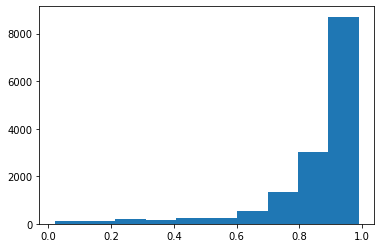

In [7]:
plt.hist(df["grad_rate"])

In [8]:
#before training our model, we need to numerify our categorical vars! we can do this easily w/ get_dummies: https://stackoverflow.com/questions/58101126/using-scikit-learn-onehotencoder-with-a-pandas-dataframe
categorical_features = ['school_type','magnet','urban_centric_locale','lunch_program']
for cf in categorical_features:
    if cf not in df.columns: continue #in case you're running again
    df = pd.get_dummies(df,prefix=[cf], columns=[cf])
df

,grad_rate,teachers_per_student,support_per_teacher,log_math_pass,log_read_pass,avg_salaries_admin_per_student,avg_teacher_salaries,logit_grad_rate,school_type_Other/alternative,school_type_Regular,school_type_Vocational,magnet_no,magnet_yes,urban_centric_locale_City,urban_centric_locale_Rural,urban_centric_locale_Suburb,urban_centric_locale_Town,lunch_program_no,lunch_program_yes
0,0.94,0.053621,0.300390,3.610918,3.465736,254.245125,49103.324675,2.751535,0,1,0,1,0,0,0,0,1,0,1
1,0.95,0.052045,0.178571,3.737670,3.295837,279.946736,55422.250000,2.944439,0,1,0,1,0,0,1,0,0,1,0
2,0.87,0.050761,0.166667,3.610918,3.737670,275.516629,55165.800000,1.900959,0,1,0,1,0,0,1,0,0,1,0
3,0.97,0.053452,0.208333,4.043051,4.043051,333.421423,52355.166667,3.476099,0,1,0,1,0,0,1,0,0,1,0
4,0.87,0.049521,0.129032,3.737670,3.091042,264.346570,49686.709677,1.900959,0,1,0,1,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14666,0.75,0.147059,0.704667,3.901973,3.901973,3685.318627,48781.400000,1.098612,0,1,0,1,0,0,1,0,0,0,1
14667,0.92,0.072165,0.622449,4.094345,4.143135,493.097202,74499.387755,2.442347,0,1,0,1,0,0,1,0,0,0,1
14668,0.74,0.148936,0.714286,3.401197,2.302585,2370.468085,81567.285714,1.045969,0,1,0,1,0,0,0,0,1,0,1
14669,0.90,0.153846,0.816667,3.795489,3.795489,975.961538,52946.916667,2.197225,0,1,0,1,0,0,1,0,0,0,1


### Model 1: All Predictors

(array([  16.,   87.,  116.,  374.,  486., 1485., 3175., 4096., 4319.,
         517.]),
 array([-3.8918203 , -3.04312628, -2.19443227, -1.34573825, -0.49704424,
         0.35164978,  1.20034379,  2.04903781,  2.89773182,  3.74642584,
         4.59511985]),
 <BarContainer object of 10 artists>)

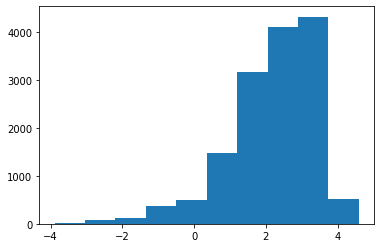

In [9]:
plt.hist(df["logit_grad_rate"])

In [10]:
X = df.drop(["grad_rate","logit_grad_rate"], axis=1)
y = df["logit_grad_rate"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=18)

In [11]:
m1 = LinearRegression()
m1.fit(X_train, y_train)
m1.score(X_test, y_test)

0.35618861146643577

### Model 2: Most Predictors

In [12]:
X = df.drop(["grad_rate","logit_grad_rate","avg_teacher_salaries","magnet_no","magnet_yes","lunch_program_no","lunch_program_yes"], axis=1)
y = df["logit_grad_rate"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=18)

In [13]:
m2 = LinearRegression()
m2.fit(X_train, y_train)
m2.score(X_test, y_test)

0.3585486937701654

### Model 3: Just Reading and Math

In [14]:
X = df[["log_math_pass","log_read_pass"]]
y = df["logit_grad_rate"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=18)

In [15]:
m3 = LinearRegression()
m3.fit(X_train, y_train)
m3.score(X_test, y_test)

0.24085323052135355

## K-Fold Cross Validation

In [16]:
#got help from: https://isheunesu48.medium.com/cross-validation-using-k-fold-with-scikit-learn-cfc44bf1ce6
feature_sets = [
    ['teachers_per_student',
     'support_per_teacher',
     'log_math_pass',
     'log_read_pass',
     'avg_salaries_admin_per_student',
     'avg_teacher_salaries',
     'school_type_Other/alternative',
     'school_type_Regular',
     'school_type_Vocational',
     'magnet_no',
     'magnet_yes',
     'urban_centric_locale_City',
     'urban_centric_locale_Rural',
     'urban_centric_locale_Suburb',
     'urban_centric_locale_Town',
     'lunch_program_no',
     'lunch_program_yes'],
    ['teachers_per_student',
     'support_per_teacher',
     'log_math_pass',
     'log_read_pass',
     'avg_salaries_admin_per_student',
     'school_type_Other/alternative',
     'school_type_Regular',
     'school_type_Vocational',
     'urban_centric_locale_City',
     'urban_centric_locale_Rural',
     'urban_centric_locale_Suburb',
     'urban_centric_locale_Town'],
    ['log_math_pass',
     'log_read_pass']
]

In [53]:
def all_models_repK(df: pd.DataFrame, feature_sets: list, n_repeats: int, n_splits: int):
    """Runs n_repeats repetitions of k-fold cross validations where k=n_splits."""
    #data prep N
    scores = []
    for feature_set in feature_sets:
        X,y = df[feature_set],df["logit_grad_rate"]
        model = LinearRegression()
        rkf = RepeatedKFold(n_repeats=n_repeats,n_splits=n_splits)
        score = cross_val_score(model, X, y, cv=rkf)
        scores.append(score)
    return scores

In [54]:
all_models_repK(df, feature_sets, 50, 10)

[array([0.26326997, 0.35928993, 0.38532829, 0.28991843, 0.33924746,
        0.38058092, 0.35945088, 0.3470863 , 0.32906822, 0.39727765,
        0.3256565 , 0.33952073, 0.14914109, 0.37114949, 0.32859261,
        0.37407069, 0.36446556, 0.37876512, 0.38568274, 0.39303615,
        0.34391677, 0.36257982, 0.37179922, 0.29022379, 0.37837089,
        0.34134095, 0.37472266, 0.3431012 , 0.30574545, 0.37679937,
        0.34375715, 0.16944857, 0.30731107, 0.38790722, 0.35713433,
        0.37221828, 0.33888015, 0.33690359, 0.39802206, 0.38492879,
        0.36508999, 0.33777493, 0.41560098, 0.38660592, 0.34820319,
        0.15880558, 0.35299057, 0.37743702, 0.35222098, 0.3426302 ,
        0.32377599, 0.38600078, 0.36537601, 0.40126574, 0.27001661,
        0.36659204, 0.32596314, 0.35233581, 0.36684006, 0.35354181,
        0.35613641, 0.21694613, 0.36288013, 0.38544533, 0.34945775,
        0.33022194, 0.36253342, 0.39639756, 0.37754245, 0.34103359,
        0.34850977, 0.22061283, 0.39576642, 0.38

Looks like our non-parallelized version runs well!

## Parallelization

In [19]:
import multiprocessing
multiprocessing.cpu_count()

8

In [55]:
def run_jobs(n_jobs: int):
    """High-level function which parallelizes all_models_repK for n_jobs."""
    #links for joblib
    #https://stackoverflow.com/questions/67237020/how-to-parallelize-multiple-model-building-procedures-in-sklearn
    #https://stackoverflow.com/questions/42220458/what-does-the-delayed-function-do-when-used-with-joblib-in-python

    
    #TODO: parameterize df, feature_sets, r, 10
    results = Parallel(n_jobs=n_jobs)(delayed(all_models_repK)(df, feature_sets, r, 10) for r in [17,17,16])
    return results

In [56]:
partition_results = run_jobs(3)

ideas:

In [66]:
model_results = [[] for i in range(len(partition_results))]
for partition_result in partition_results:
    for model_index,model_result in enumerate(partition_results):
        model_results[model_index].append(model_result)

In [ ]:
    unified_results = {i:[] for i in range(1,len(scores)+1)}
    for fold_results in results:
        for model_index in range(len(feature_sets)):
            unified_results[model_index+1].extend(results[model_index])
            
    #flatten out numpy arrays leftover from n_job splits
    for model_index in range(1,len(unified_results)+1):
        unified_results[model_index] = np.concatenate(unified_results[model_index]).ravel().tolist()
    return unified_results